In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import numpy as np
import scipy.optimize as sco
import glob
import json
import os

Text(0, 0.5, 'net')

/Users/carllx/opt/anaconda3/envs/fund_cn_analytics/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 23433 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/carllx/opt/anaconda3/envs/fund_cn_analytics/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20449 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/carllx/opt/anaconda3/envs/fund_cn_analytics/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 26032 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/carllx/opt/anaconda3/envs/fund_cn_analytics/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 22238 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/carllx/opt/anaconda3/envs/fund_cn_analytics/lib/python3.8/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 25253 missing f

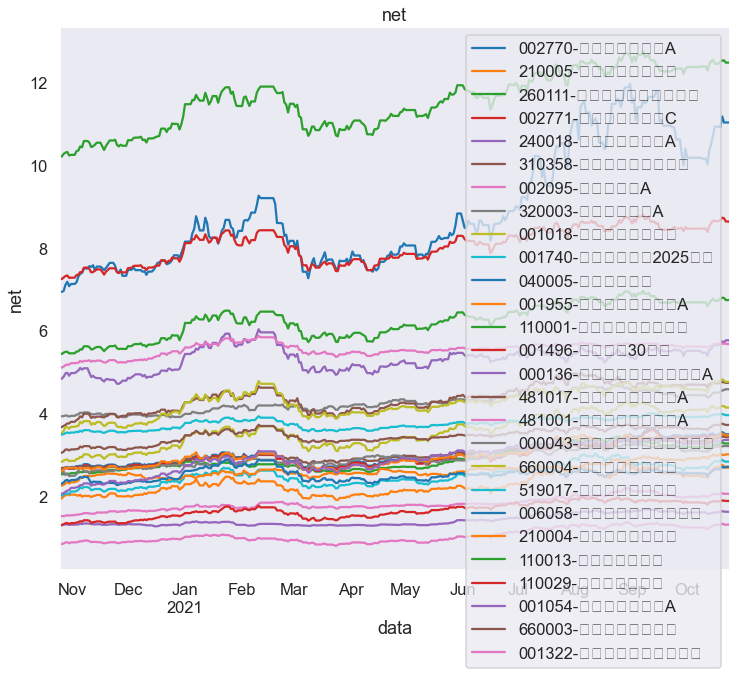

In [4]:
from pathlib import Path
# Support both running from repo root, experiment root, or notebooks folder
possible_paths = ["../report/NET/", "report/NET/", "../../report/NET/"]
PATH_NET_FOLDER = next((p for p in possible_paths if os.path.exists(p)), "../report/NET/")
NETS = glob.glob(PATH_NET_FOLDER + "*.json")
frames = []
for path in NETS:
    f = open (path, "r")
    fname = os.path.basename(path).split(".")[0]
    res = json.loads(f.read())
    data = res["data"]
    df = pd.DataFrame(data,columns=["FSRQ","LJJZ"])
    df.rename(columns={'FSRQ':'date','LJJZ':fname}, inplace = True)
    
    df['date'] = pd.to_datetime(df["date"],  format='%Y-%m-%d')
    df = df.set_index("date")
    df[fname] = pd.to_numeric(df[fname], downcast="float")
    _df_1year = pd.date_range(end = datetime.datetime.today().strftime("%Y-%m-%d"), periods=365*1, freq='D')# 创建从今天算起2年的时间序列
    df = df.reindex(_df_1year).bfill().ffill()# 向前填充，向后填充
    
    frames.append(df)

if len(frames) > 0:
    portfolio = pd.concat(frames,axis=1, join="inner")
    sns.set_style("darkgrid")
    sns.set_context("talk")
    plt=portfolio.plot(figsize=(12,10),title="net",grid=False)
    plt.set_xlabel('data')
    plt.set_ylabel('net')
else:
    print(f"No net data found under {PATH_NET_FOLDER}")
